In [1]:
#%matplotlib widget
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import ExponentialModel, LorentzianModel, \
    GaussianModel, PseudoVoigtModel, PowerLawModel, LinearModel
import copy
import hyperspy.api as hs

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

In [2]:
ev2cmi = 8065.54429 #cm⁻¹
def ev_to_cmi(eV):
    """
    Convert energy from electron volts (eV) to wavenumbers in reciprocal centimeters (cm⁻¹).
    """
    cm_inverse = eV * ev2cmi
    return cm_inverse

def cmi_to_ev(cmi):
    """
    Convert energy from electron volts (eV) to wavenumbers in reciprocal centimeters (cm⁻¹).
    """
    ev = cmi / ev2cmi
    return ev

In [3]:
def plot_eels_fit(x1, y1, out):
    f, ax2 = plt.subplots(1,2,figsize=(10,5)) 
    
    #dif line offset on the plot
    dif_off = (0.75 * y1[-1])
    
    ax2[0].plot(x1, y1, 'k.', markersize=3, label='vibEELS data')
    ax2[0].plot(x1, out.best_fit, 'r-', lw=1, label='best fit', zorder=99)
    ax2[0].plot(x1, y1 - out.best_fit + dif_off, 'k-', lw=1, label='residue')

    components = out.eval_components(x=x1)
    ax2[1].plot(x1, y1-components['bg_'], 'k-', label='_nolegend_', zorder=99)

    for model_name, model_value in components.items():
        if model_name == 'bg_':
            ax2[0].plot(x1, model_value,'b-', lw=1, label='background')
        else:
            peak_position = ev_to_cmi( out.__dict__['best_values']['{:s}center'.format(model_name)] )
            print(model_name, ' = ', peak_position, ' cm-1')
            # if peak name is needed, use the following line
            # ax2[1].plot(x1, model_value, '-', lw=1, label=model_name[:-1] + 
            #             ", {:.0f} ".format(np.round(peak_position, decimals=0)) + 'cm$^\mathdefault{-1}$')

            # if peak name is NOT needed, use the following line
            ax2[1].plot(x1, model_value, '-', lw=1, label= "{:.0f} ".format(np.round(peak_position, decimals=0)) + 'cm$^\mathdefault{-1}$')
            

    secax = []
    label_font_size = 15
    for i in range(2):
        ax2[i].set_xlabel('Energy (eV)', fontsize=label_font_size)
        ax2[i].set_ylabel('Intensity (arbitrary unit)', fontsize=label_font_size)
        ax2[i].set_yticks([])
        visible_ticks = {"top": False}
        ax2[i].tick_params(axis="x", which="both", **visible_ticks, labelsize=label_font_size)
        secax.append(ax2[i].secondary_xaxis('top', functions=(ev_to_cmi, cmi_to_ev)))
        secax[i].set_xlabel('Wavenumber (cm$^\mathdefault{-1}$)', fontsize=label_font_size)
        secax[i].tick_params(labelsize=label_font_size)
        # ax2[i].axes.legend(fontsize=10, handlelength=1.0)
    
    plt.tight_layout()
    # plt.tight_layout()
    # plt.legend(fontsize=8)
    
    return(f, ax2)
    
def plot_eels_quick(x1, y1):
    f, ax = plt.subplots(1,1,figsize=(5,3)) 
    ax.plot(x1, y1)
    ax.set_xlabel('Energy (eV)')
    ax.set_ylabel('Intensity (arbitrary unit)')
    ax.set_yticks([])
    visible_ticks = {"top": False}
    ax.tick_params(axis="x", which="both", **visible_ticks)
    secax = ax.secondary_xaxis('top', functions=(ev_to_cmi, cmi_to_ev))
    secax.set_xlabel('Wavenumber (cm$^\mathdefault{-1}$)')
    plt.tight_layout()

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
C:\Users\34229\AppData\Local\Temp\ipykernel_30972\2491340423.py:25: SyntaxWarning: invalid escape sequence '\m'
  ax2[1].plot(x1, model_value, '-', lw=1, label= "{:.0f} ".format(np.round(peak_position, decimals=0)) + 'cm$^\mathdefault{-1}$')
C:\Users\34229\AppData\Local\Temp\ipykernel_30972\2491340423.py:37: SyntaxWarning: invalid escape sequence '\m'
  secax[i].set_xlabel('Wavenumber (cm$^\mathdefault{-1}$)', fontsize=label_font_size)
C:\Users\34229\AppData\Local\Temp\ipykernel_30972\2491340423.py:56: SyntaxWarning: invalid escape sequence '\m'
  secax.set_xlabel('Wavenumber (cm$^\mathdefault{-1}$)')


# Read EELS data

In [5]:
s = hs.load("./None_001_Spectrum-Stack_2023-06-13T141257.986501_90x512x1028_2.dm3")
s.set_signal_type("EELS")
haadf = hs.load("./None_S4_quartz_001_Display-Snapshot-of-SuperScan-HAADF_2023-06-13T140911.942433_512x512_3.dm3")
s

C:\Users\34229\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


WARNING | Hyperspy | `signal_type='EELS'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:743)


<Signal2D, title: , dimensions: (90|1028, 512)>

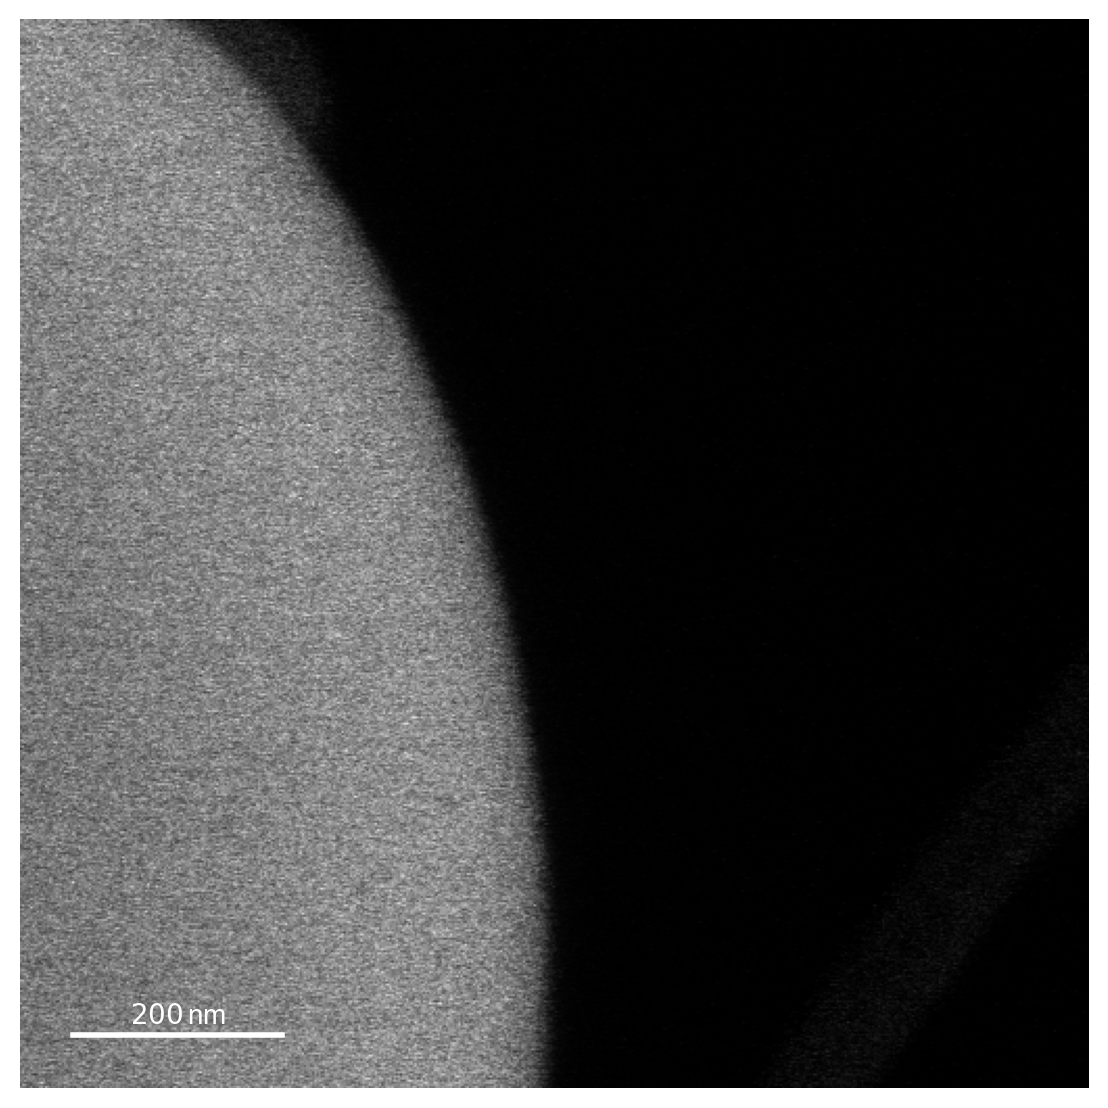

In [6]:
haadf.plot(title='', colorbar=False)
ax = plt.gca()
ax.axis('off')
plt.tight_layout
plt.savefig('TEM image.png', bbox_inches='tight', transparent=True)

(x, y, wavenumber), in this case, it looks like line scan is done, instead of 2D scan.  512 is for the dimension of the CCD detector image.

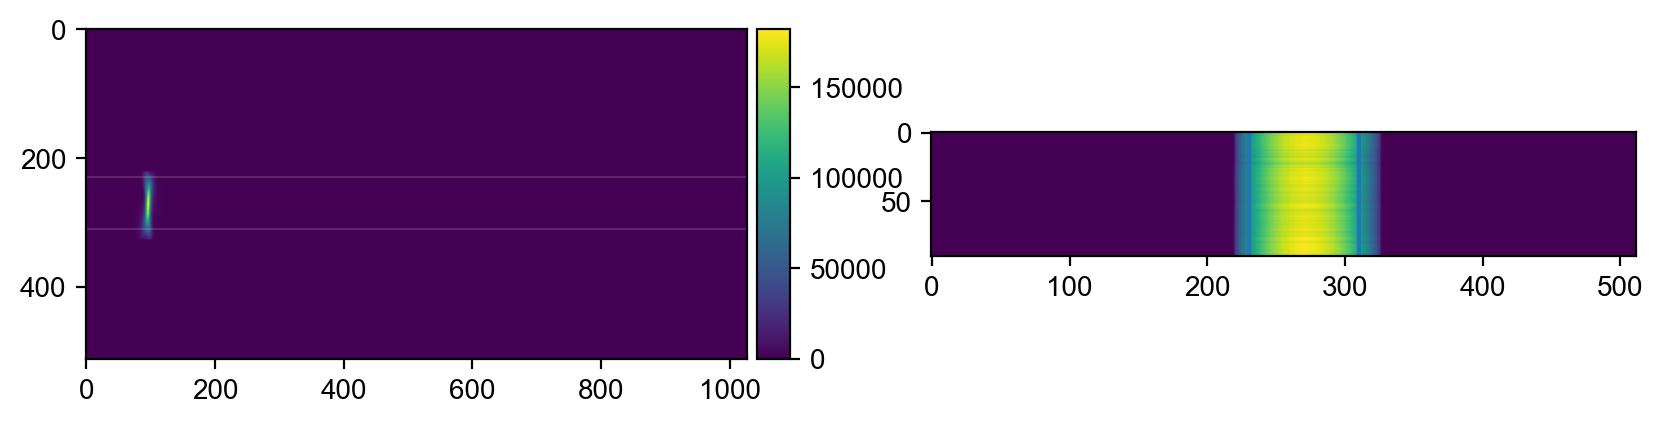

In [8]:
roi_i = (230,310)

from mpl_toolkits.axes_grid1 import make_axes_locatable
f, axs = plt.subplots(1,2, figsize=(10,3))
im = axs[0].imshow(s.data[10,:,:])
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax)
axs[0].axhline(roi_i[0], lw=0.1, c='w'); axs[0].axhline(roi_i[1], lw=0.1, c='w')

pos = axs[1].imshow(s.data[:,:,:].sum(axis=2))
axs[1].axvline(x=roi_i[0]); axs[1].axvline(x=roi_i[1])

# Align data

I failed to find a way to use zero loss peak alignment function in hyperspy.  So I use somewhat inefficient way to align the spectra below.

Align individual CCD images (30).

In [11]:
# s_temp1 = []

# for i in range(s.data.shape[0]):
#     s_temp = hs.signals.Signal1D(s.data[i,roi_i[0]:roi_i[1],:])
#     s_temp.align1D(crop=False, fill_value=0.)
#     s_temp1.append(s_temp.data)

In [12]:
# Optimised code by Sibo Chen using GPT4
import numpy as np
from joblib import Parallel, delayed
import hyperspy.api as hs

# Assuming 's' is your signal object and 'roi_i' defines the region of interest

def process_signal_slice(data_slice):
    # This function will process each slice.
    # Adjust the operations here according to what's supported by your data and libraries.
    s_temp = hs.signals.Signal1D(data_slice)
    s_temp.align1D(crop=False, fill_value=0.)
    return s_temp.data

# Prepare your data slices in advance
data_slices = [s.data[i, roi_i[0]:roi_i[1], :] for i in range(s.data.shape[0])]

# Use Parallel processing to process each slice
# n_jobs=-1 will use all available CPU cores
s_temp1 = Parallel(n_jobs=-1)(delayed(process_signal_slice)(slice) for slice in data_slices)


In [13]:
s_temp1 = np.asarray(s_temp1)
s_temp2 = hs.signals.Signal2D(s_temp1)
shifts = s_temp2.estimate_shift2D()
s_temp2.align2D(shifts=shifts,crop=False, fill_value=0.)

  0%|          | 0/90 [00:00<?, ?it/s]

[########################################] | 100% Completed | 102.28 ms


The alignment above does not change in a snapshot.  But alignment takes care of difference between snapshots.

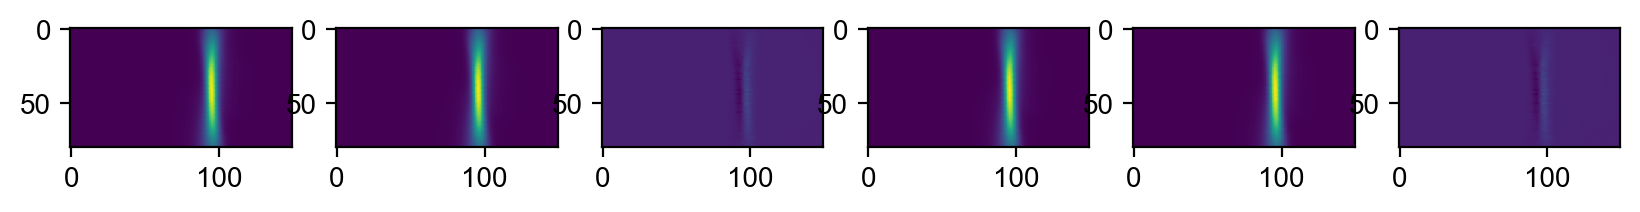

In [15]:
i_max = 150

f, axs = plt.subplots(1,6, figsize=(10,3))
axs[0].imshow(s_temp2.data[0,:,:i_max]) #
axs[1].imshow(s_temp2.data[10,:,:i_max]) #
axs[2].imshow(s_temp2.data[0,:,:i_max]-s_temp2.data[20,:,:i_max], vmax=s_temp2.data[10,:,:i_max].max()) #
axs[3].imshow(s_temp1[0,:,:i_max]) #
axs[4].imshow(s_temp1[10,:,:i_max]) #
axs[5].imshow(s_temp1[0,:,:i_max]-s_temp1[20,:,:i_max], vmax=s_temp1[10,:,:i_max].max()) #

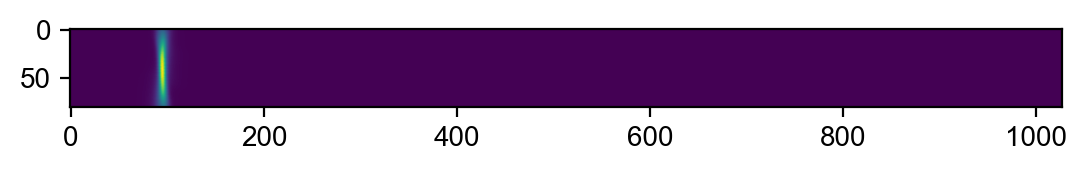

In [16]:
f = plt.figure()
plt.imshow(s_temp2.data[0,:,:]) #

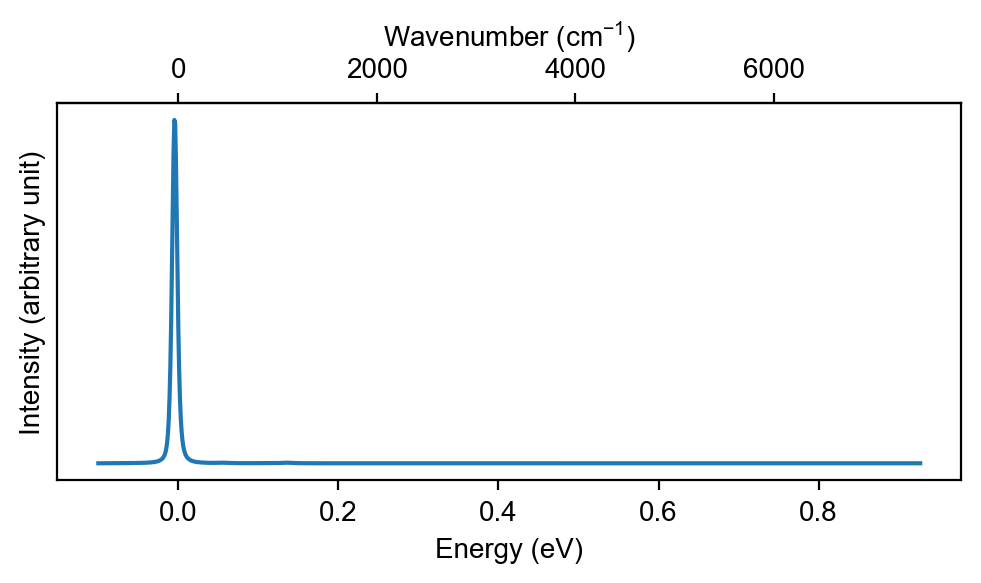

In [17]:
test = s_temp2.data[:,:,:].sum(axis=0).sum(axis=0)

wn_raw = np.arange(len(test))*0.001 - 0.1
inten = test
plot_eels_quick(wn_raw, test)

# Zero loss peak fitting

p1_  =  -36.927424793028706  cm-1


(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: xlabel='Energy (eV)', ylabel='Intensity (arbitrary unit)'>,
        <Axes: xlabel='Energy (eV)', ylabel='Intensity (arbitrary unit)'>],
       dtype=object))

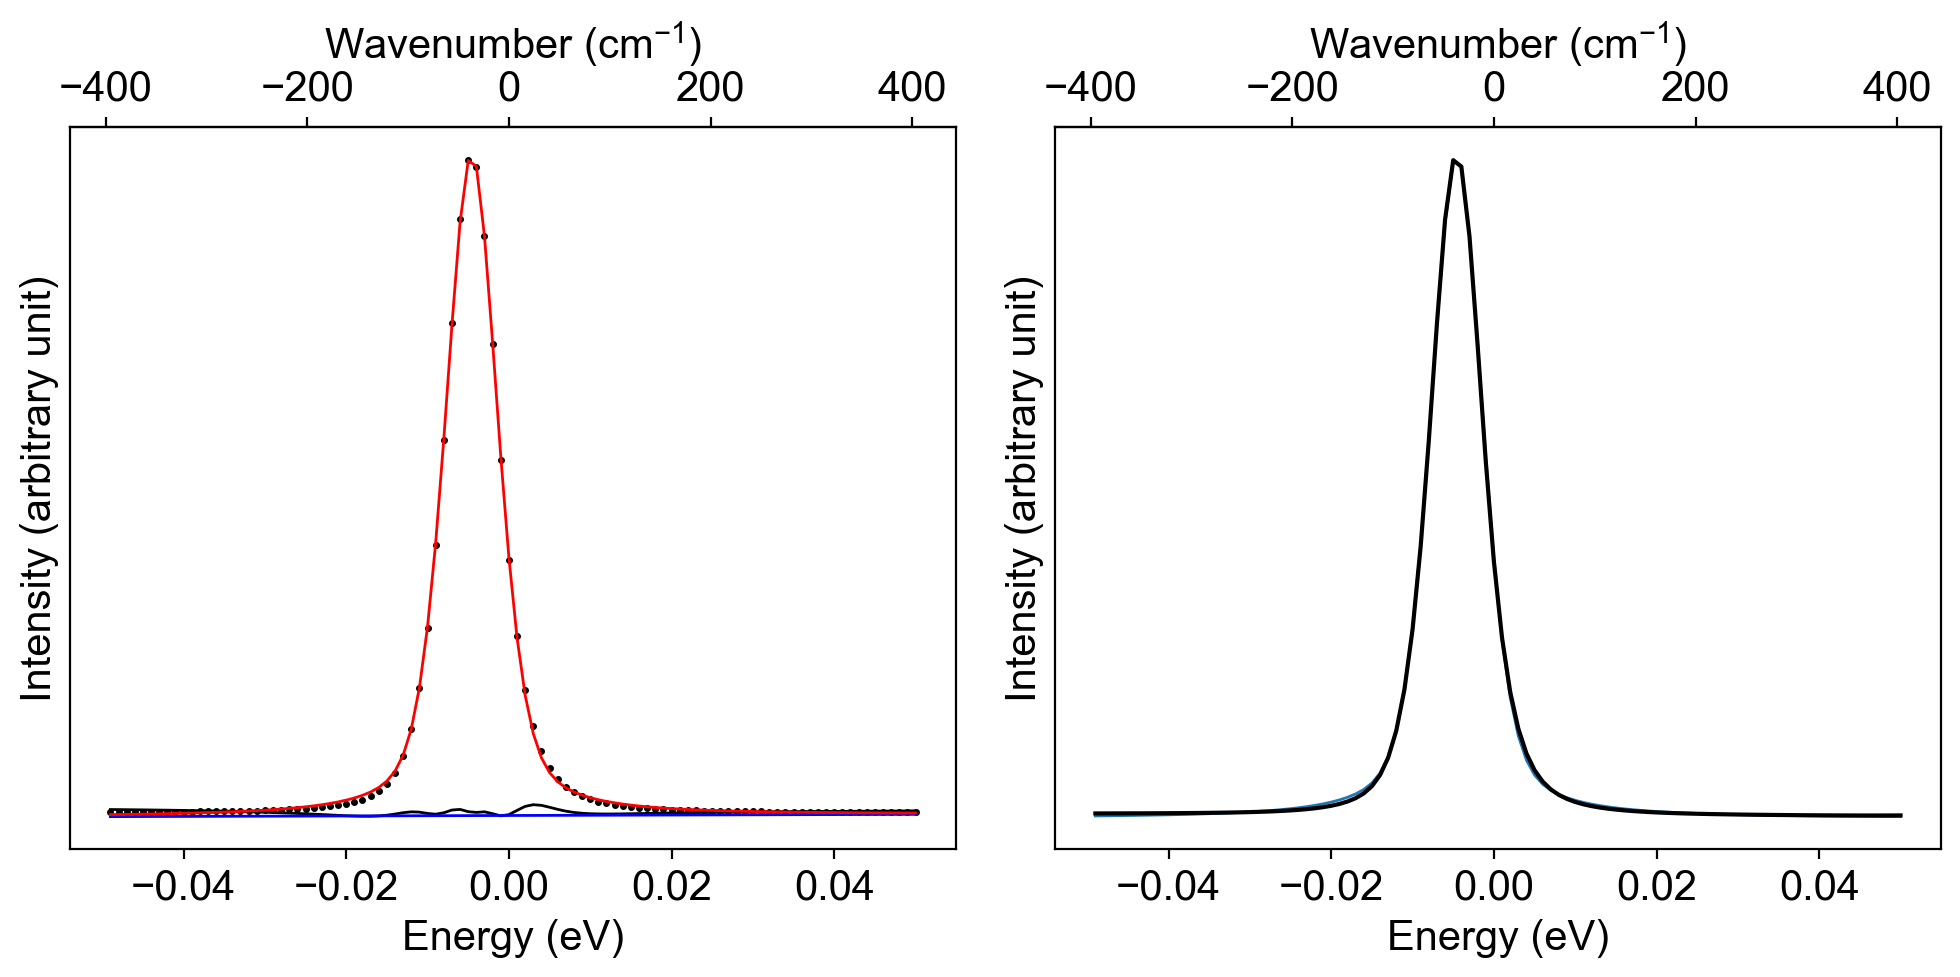

In [19]:
roi = ((wn_raw > -0.05) & (wn_raw < 0.05))
x1 = wn_raw[roi]; y1 = inten[roi]

roi = (x1 > -0.04) & (x1 < 0.04)
bg = LinearModel(prefix='bg_') # from lmfit
pars_bg = bg.guess(y1[roi], x=x1[roi]) # making intial values for linear background function
peak = PseudoVoigtModel(prefix='p1_') # define peak shape
pars_peak = peak.guess(y1[roi], x=x1[roi]) # making initial values for peak number 1

pars = pars_peak + pars_bg # collect parameters for peaks and background
mod = peak + bg # collect features in spectrum
out = mod.fit(y1, pars, x=x1) # performs fitting

plot_eels_fit(x1, y1, out) # plot fitting result

In [20]:
print(out.fit_report(min_correl=0.5))

[[Model]]
    (Model(pvoigt, prefix='p1_') + Model(linear, prefix='bg_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 36
    # data points      = 100
    # variables        = 6
    chi-square         = 8.1912e+14
    reduced chi-square = 8.7140e+12
    Akaike info crit   = 2985.40798
    Bayesian info crit = 3001.03900
    R-squared          = 0.99979843
[[Variables]]
    p1_amplitude:  8892424.41 +/- 35319.1826 (0.40%) (init = 1.175995e+07)
    p1_center:    -0.00457842 +/- 6.6513e-06 (0.15%) (init = -0.0045)
    p1_sigma:      0.00384564 +/- 1.0513e-05 (0.27%) (init = 0.0035)
    p1_fraction:   0.50472976 +/- 0.00991160 (1.96%) (init = 0.5)
    p1_fwhm:       0.00769127 +/- 2.1025e-05 (0.27%) == '2.0000000*p1_sigma'
    p1_height:     9.0944e+08 +/- 1841166.72 (0.20%) == '(((1-p1_fraction)*p1_amplitude)/max(1e-15, (p1_sigma*sqrt(pi/log(2))))+(p1_fraction*p1_amplitude)/max(1e-15, (pi*p1_sigma)))'
    bg_slope:      31708320.6 +/- 10376373.3 (32.72%) (i

In [21]:
wn_shift = out.__dict__['best_values']['p1_center']
wn = wn_raw - wn_shift

# Plot ROI and fit

May not improve as much from UI output.  That means the UI takes care of alignment issue internally.

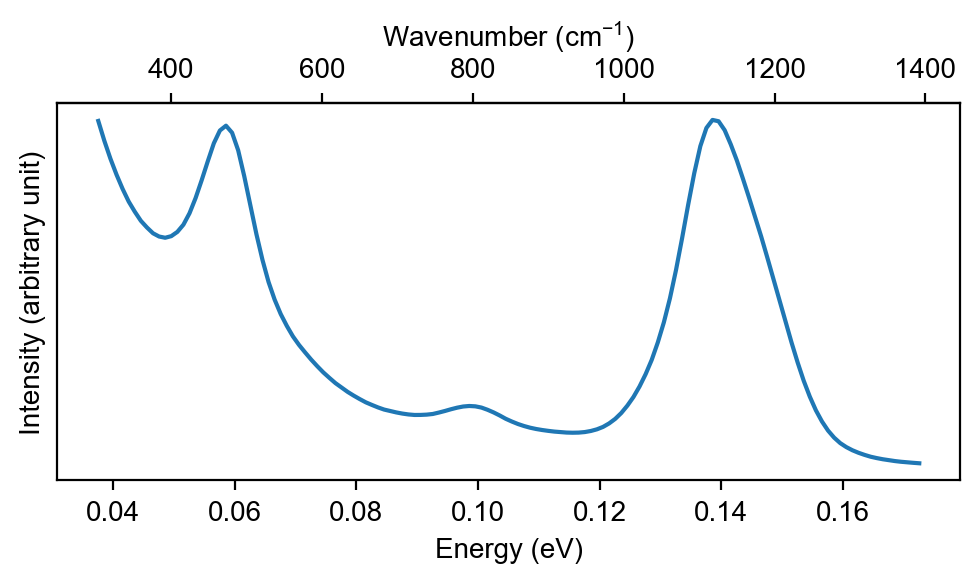

In [78]:
roi = ((wn > cmi_to_ev(300)) & (wn <cmi_to_ev(1400)))
x1 = wn[roi]; y1 = inten[roi]
plot_eels_quick(x1, y1)

p1_  =  475.024527302874  cm-1
p2_  =  802.6528420303363  cm-1
p3_  =  1112.262443556311  cm-1
p4_  =  1180.4622369703354  cm-1


(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: xlabel='Energy (eV)', ylabel='Intensity (arbitrary unit)'>,
        <Axes: xlabel='Energy (eV)', ylabel='Intensity (arbitrary unit)'>],
       dtype=object))

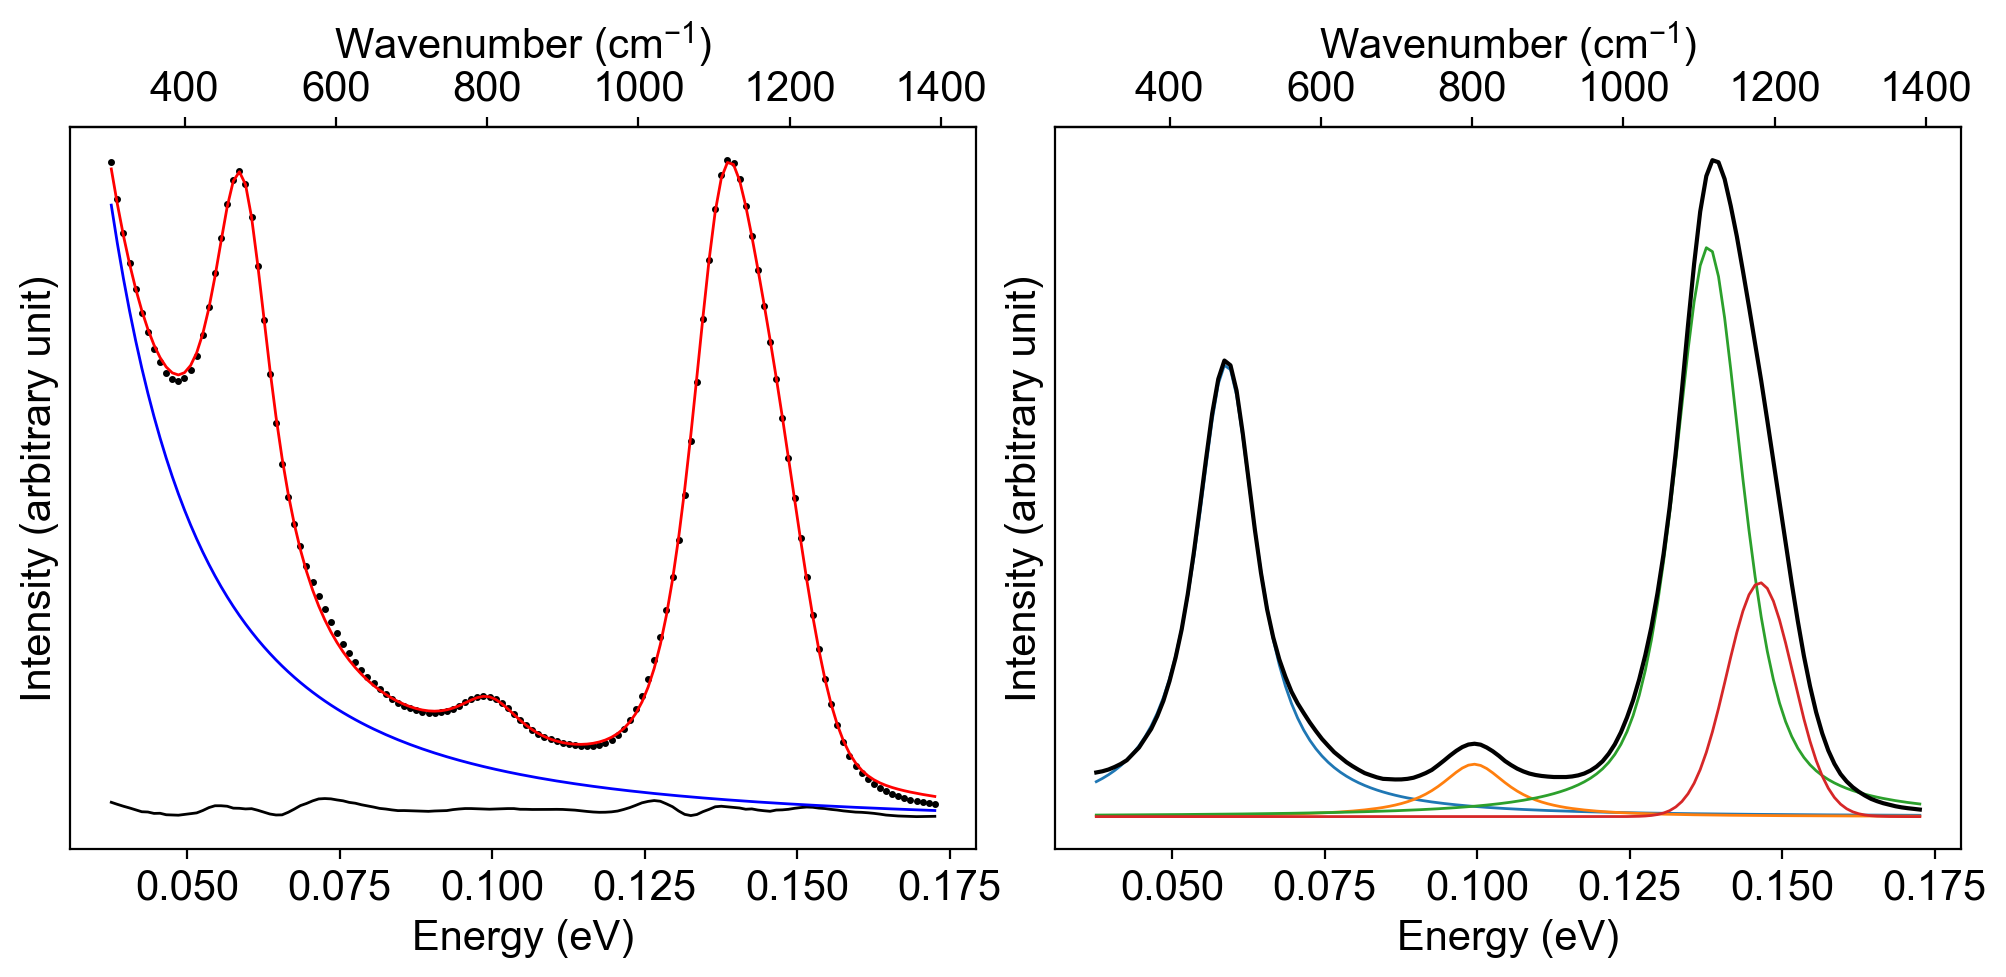

In [79]:
peak1 = PseudoVoigtModel(prefix='p1_')
peak2 = PseudoVoigtModel(prefix='p2_')
peak3 = PseudoVoigtModel(prefix='p3_')
peak4 = PseudoVoigtModel(prefix='p4_')

# background
roi = (x1 < cmi_to_ev(400)) | (x1 > cmi_to_ev(1350))
#bg_mod = ExponentialModel(prefix='bg_')
bg_mod = PowerLawModel(prefix='bg_')
pars_bg = bg_mod.guess(y1[roi], x=x1[roi])

# peak1
roi = (x1 > cmi_to_ev(450)) & (x1 < cmi_to_ev(500))
pars_p1 = peak1.guess(y1[roi], x=x1[roi])
pars_p1['p1_center'].set(min=cmi_to_ev(450), max=cmi_to_ev(500))
pars_p1['p1_amplitude'].set(min=0.0)
# peak2
roi = (x1 > cmi_to_ev(750)) & (x1 < cmi_to_ev(850))
pars_p2 = peak2.guess(y1[roi], x=x1[roi])
# peak3
roi = (x1 > cmi_to_ev(1100)) & (x1 < cmi_to_ev(1150))
pars_p3 = peak3.guess(y1[roi], x=x1[roi])
# peak4
roi = (x1 > cmi_to_ev(1150)) & (x1 < cmi_to_ev(1200))
pars_p4 = peak4.guess(y1[roi], x=x1[roi])

pars = pars_p1 + pars_p2 + pars_p3 + pars_p4 + pars_bg
mod = peak1 + peak2 + peak3 + peak4 + bg_mod
out = mod.fit(y1, pars, x=x1)

plot_eels_fit(x1, y1, out)

# Plot ROI and fit

May not improve as much from UI output.  That means the UI takes care of alignment issue internally.

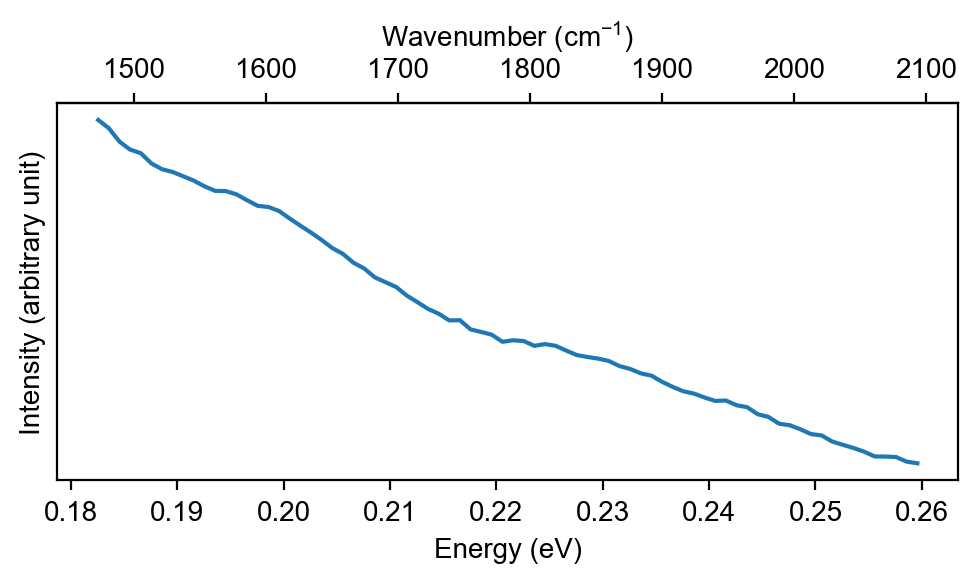

In [82]:
roi = ((wn > cmi_to_ev(1470)) & (wn <cmi_to_ev(2100)))
x1 = wn[roi]; y1 = inten[roi]
plot_eels_quick(x1, y1)

p1_  =  1618.9399575733273  cm-1
p2_  =  1854.0601428566827  cm-1
p3_  =  1961.8317426962583  cm-1


(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: xlabel='Energy (eV)', ylabel='Intensity (arbitrary unit)'>,
        <Axes: xlabel='Energy (eV)', ylabel='Intensity (arbitrary unit)'>],
       dtype=object))

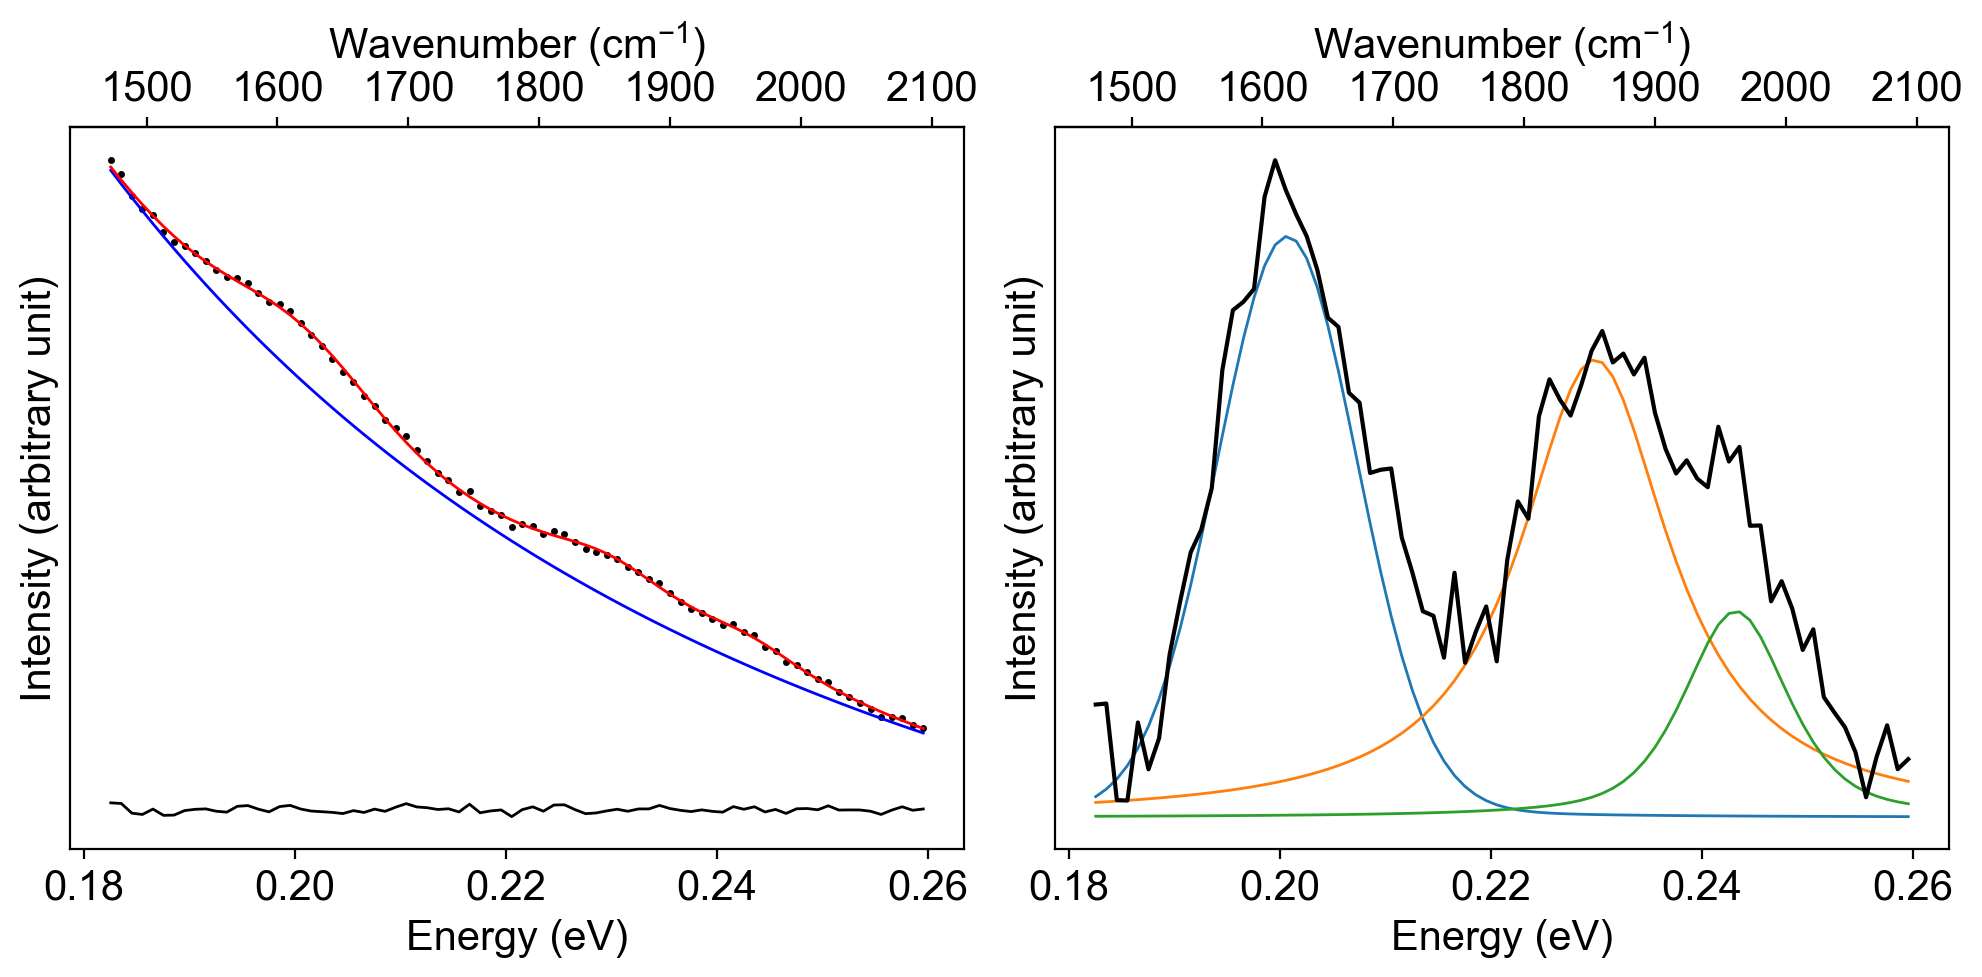

In [83]:
peak1 = PseudoVoigtModel(prefix='p1_')
peak2 = PseudoVoigtModel(prefix='p2_')
peak3 = PseudoVoigtModel(prefix='p3_')

# background
roi = (x1 < cmi_to_ev(1500)) | (x1 > cmi_to_ev(2050))
#bg_mod = ExponentialModel(prefix='bg_')
bg_mod = PowerLawModel(prefix='bg_')
pars_bg = bg_mod.guess(y1[roi], x=x1[roi])

# peak1
roi = (x1 > cmi_to_ev(1550)) & (x1 < cmi_to_ev(1700))
pars_p1 = peak1.guess(y1[roi], x=x1[roi])
pars_p1['p1_center'].set(min=cmi_to_ev(1600), max=cmi_to_ev(1650))
pars_p1['p1_amplitude'].set(min=0.0)
pars_p1['p1_fraction'].set(max=0.1)
# peak2
roi = (x1 > cmi_to_ev(1700)) & (x1 < cmi_to_ev(1900))
pars_p2 = peak2.guess(y1[roi], x=x1[roi])
pars_p2['p2_center'].set(min=cmi_to_ev(1800), max=cmi_to_ev(1900))
pars_p2['p2_sigma'].set(max=cmi_to_ev(70))
# peak3
roi = (x1 > cmi_to_ev(1900)) & (x1 < cmi_to_ev(1950))
pars_p3 = peak3.guess(y1[roi], x=x1[roi])
pars_p3['p3_center'].set(min=cmi_to_ev(1940), max=cmi_to_ev(1970))
pars_p3['p3_sigma'].set(max=cmi_to_ev(100))
pars_p3['p3_amplitude'].set(min=5.)
pars_p3['p3_fraction'].set(max=1)

pars = pars_p1 + pars_p2 + pars_p3 + pars_bg
mod = peak1 + peak2 + peak3 + bg_mod
out = mod.fit(y1, pars, x=x1)

plot_eels_fit(x1, y1, out)

# Plot ROI and fit

May not improve as much from UI output.  That means the UI takes care of alignment issue internally.

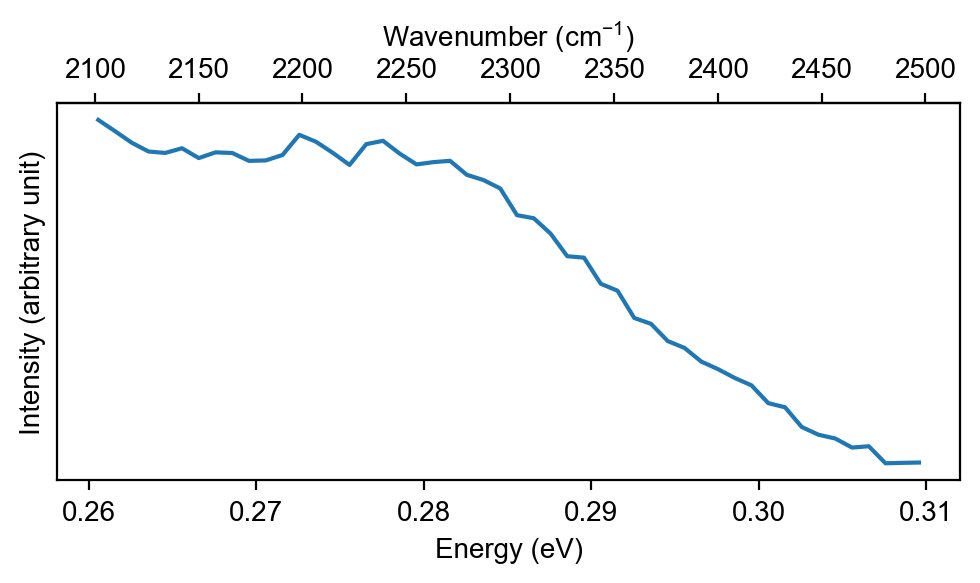

In [86]:
roi = ((wn > cmi_to_ev(2100)) & (wn <cmi_to_ev(2500)))
x1 = wn[roi]; y1 = inten[roi]
plot_eels_quick(x1, y1)

p4_  =  2219.707832150223  cm-1
p5_  =  2298.4897552585962  cm-1


(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: xlabel='Energy (eV)', ylabel='Intensity (arbitrary unit)'>,
        <Axes: xlabel='Energy (eV)', ylabel='Intensity (arbitrary unit)'>],
       dtype=object))

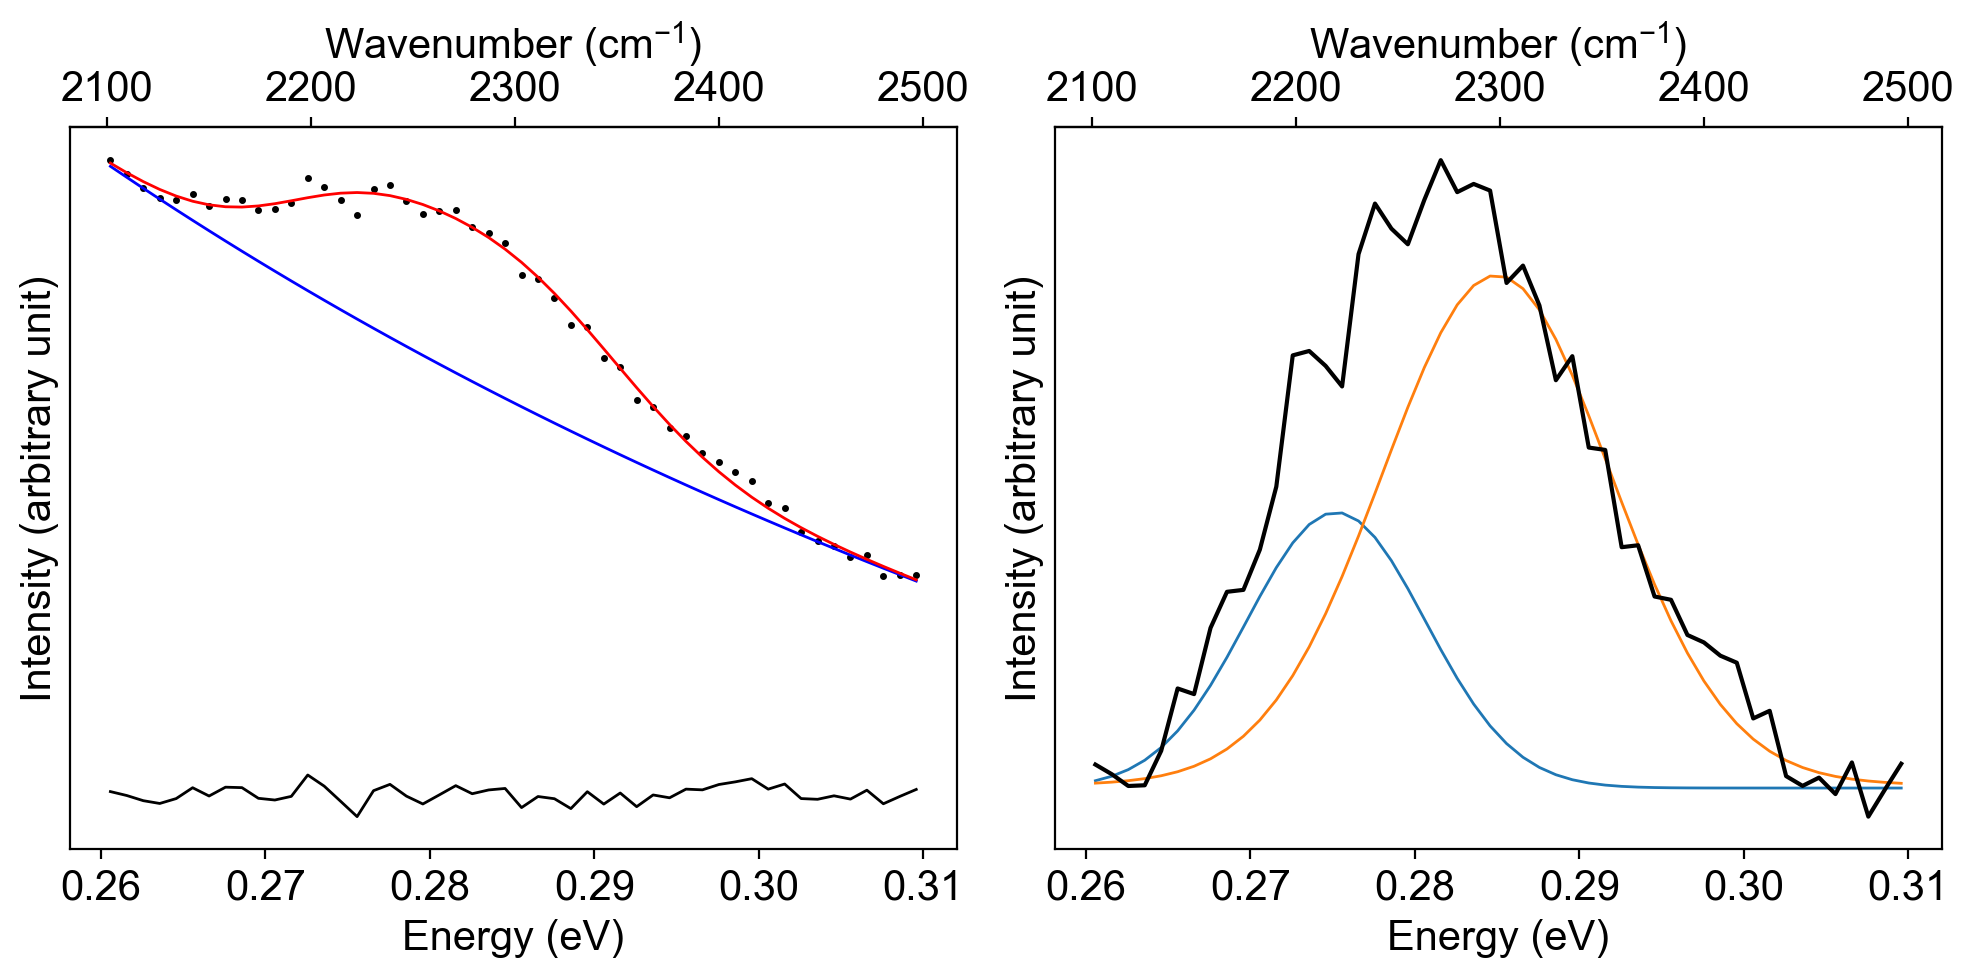

In [87]:
peak4 = PseudoVoigtModel(prefix='p4_')
peak5 = PseudoVoigtModel(prefix='p5_')

# background
roi = (x1 < cmi_to_ev(2130)) | (x1 > cmi_to_ev(2450))
#bg_mod = ExponentialModel(prefix='bg_')
bg_mod = PowerLawModel(prefix='bg_')
pars_bg = bg_mod.guess(y1[roi], x=x1[roi])

# peak4
roi = (x1 > cmi_to_ev(2200)) & (x1 < cmi_to_ev(2300))
pars_p4 = peak4.guess(y1[roi], x=x1[roi])
pars_p4['p4_center'].set(min=cmi_to_ev(2200), max=cmi_to_ev(2300))
pars_p4['p4_sigma'].set(max=cmi_to_ev(70))
pars_p4['p4_fraction'].set(max=0.1)
# peak5
roi = (x1 > cmi_to_ev(2250)) & (x1 < cmi_to_ev(2350))
pars_p5 = peak5.guess(y1[roi], x=x1[roi])
pars_p5['p5_center'].set(min=cmi_to_ev(2250), max=cmi_to_ev(2300))
pars_p5['p5_sigma'].set(max=cmi_to_ev(70))
pars_p5['p5_fraction'].set(max=0.1)

pars = pars_p4 + pars_p5 + pars_bg
mod = peak4 + peak5 + bg_mod
out = mod.fit(y1, pars, x=x1)

plot_eels_fit(x1, y1, out)

# Plot ROI and fit

May not improve as much from UI output.  That means the UI takes care of alignment issue internally.

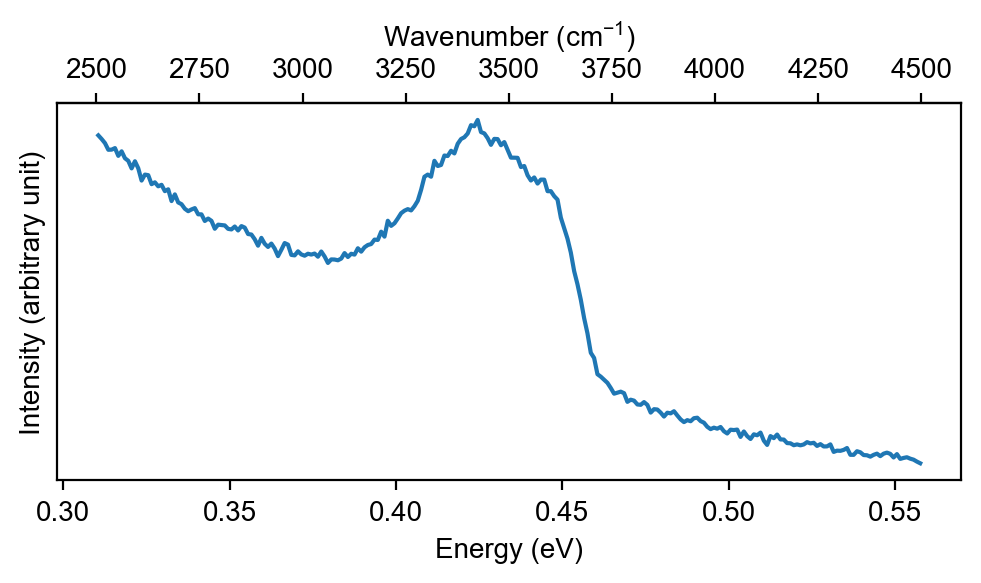

In [224]:
roi = ((wn > cmi_to_ev(2500)) & (wn <cmi_to_ev(4500)))
x1 = wn[roi]; y1 = inten[roi]
plot_eels_quick(x1, y1)

peak1_  =  3246.789201394048  cm-1
peak2_  =  3450.9844242972435  cm-1
peak3_  =  3613.260275112257  cm-1


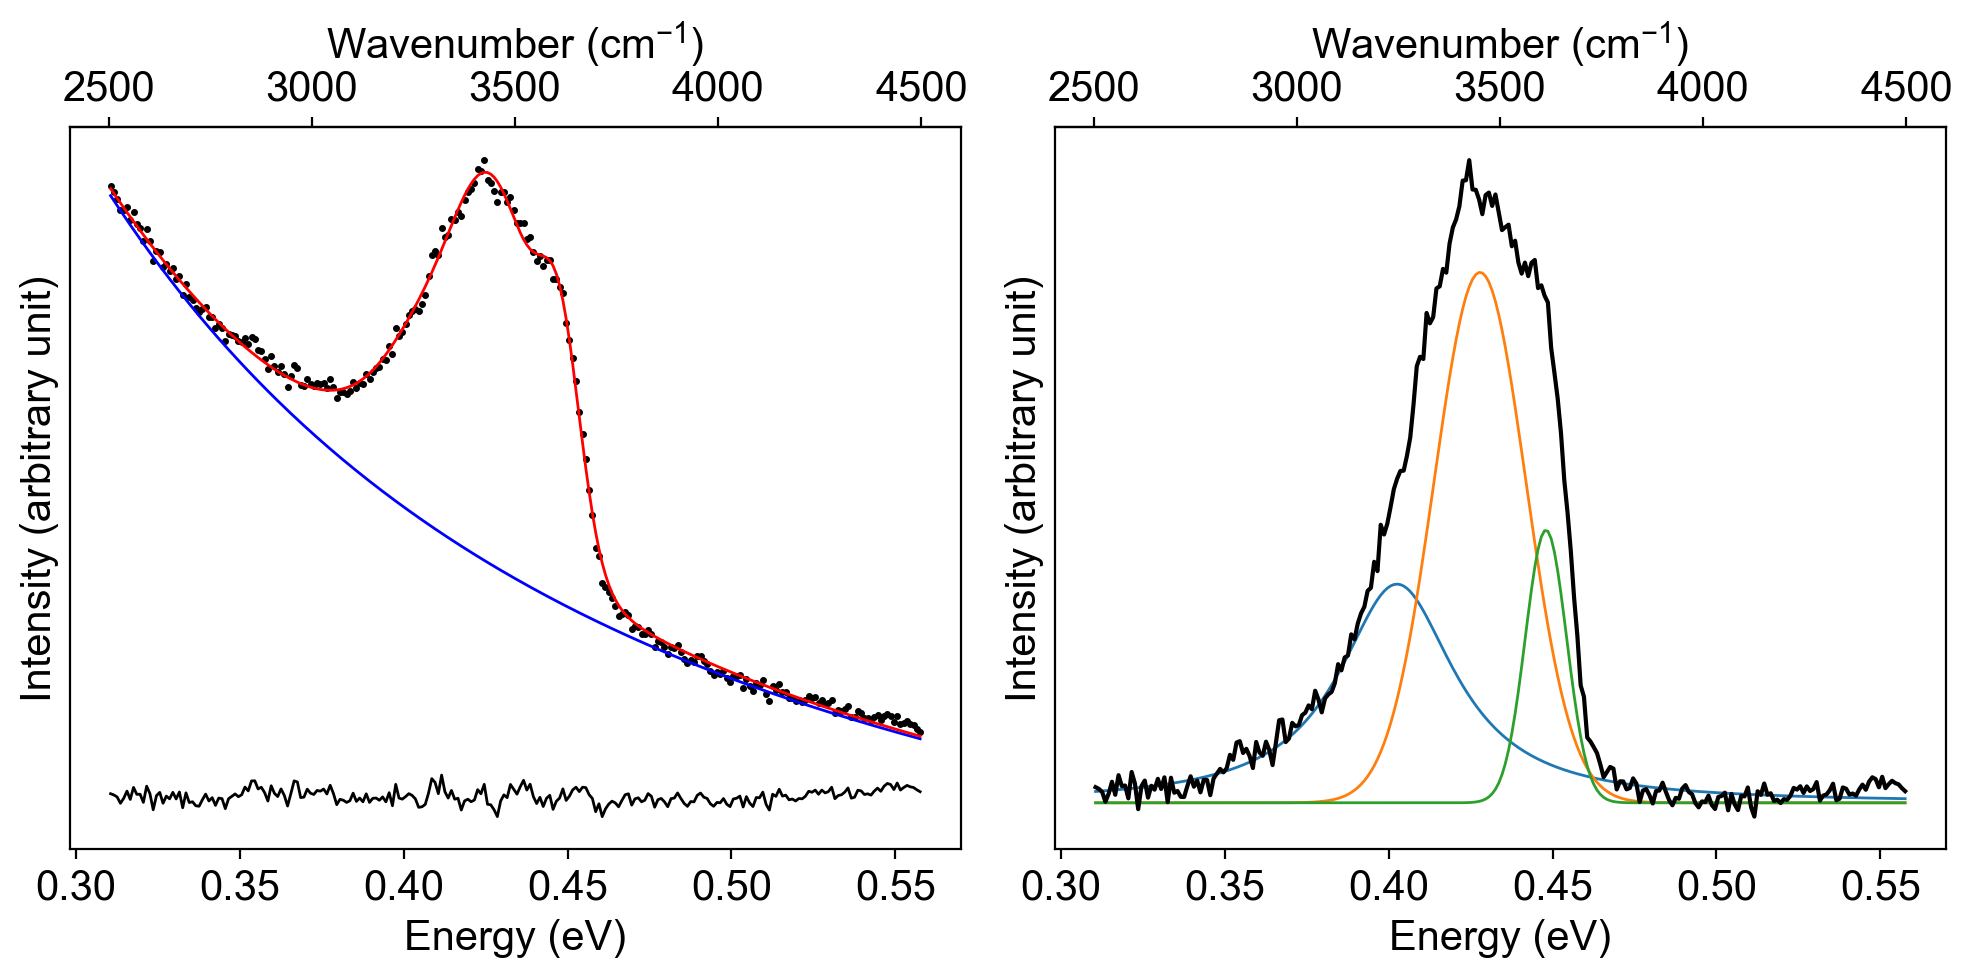

In [225]:
peak1 = PseudoVoigtModel(prefix='peak1_')
peak2 = PseudoVoigtModel(prefix='peak2_')
peak3 = PseudoVoigtModel(prefix='peak3_')

# background
roi = (x1 < cmi_to_ev(3000)) | (x1 > cmi_to_ev(3800))
#bg_mod = ExponentialModel(prefix='bg_')
bg_mod = PowerLawModel(prefix='bg_')
pars_bg = bg_mod.guess(y1[roi], x=x1[roi])

# peak1
roi = (x1 > cmi_to_ev(3200)) & (x1 < cmi_to_ev(3300))
pars_peak1 = peak1.guess(y1[roi], x=x1[roi])
pars_peak1['peak1_center'].set(min=cmi_to_ev(3200), max=cmi_to_ev(3300))
pars_peak1['peak1_sigma'].set(max=cmi_to_ev(200))
pars_peak1['peak1_fraction'].set(max=1)
# peak4
roi = (x1 > cmi_to_ev(3400)) & (x1 < cmi_to_ev(3500))
pars_peak2 = peak2.guess(y1[roi], x=x1[roi])
pars_peak2['peak2_center'].set(min=cmi_to_ev(3450), max=cmi_to_ev(3550))
pars_peak2['peak2_sigma'].set(max=cmi_to_ev(200))
pars_peak2['peak2_fraction'].set(max=1)
# peak5
roi = (x1 > cmi_to_ev(3500)) & (x1 < cmi_to_ev(3600))
pars_peak3 = peak3.guess(y1[roi], x=x1[roi])
pars_peak3['peak3_center'].set(min=cmi_to_ev(3450), max=cmi_to_ev(3650))
pars_peak3['peak3_sigma'].set(max=cmi_to_ev(200))
pars_peak3['peak3_fraction'].set(max=1)
pars_peak3['peak3_amplitude'].set(min=1)

pars = pars_peak1 + pars_peak2 + pars_peak3 + pars_bg
mod = peak1 + peak2 + peak3 + bg_mod
out = mod.fit(y1, pars, x=x1)

fig, ax2 = plot_eels_fit(x1, y1, out)

# fig.savefig('SiO2 glass ball.pdf', format='pdf', bbox_inches='tight', transparent=True)

In [226]:
# import pandas as pd
# file_path = './SiO2 glass FTIR_Murakami2018..csv'
# ir_data = pd.read_csv(file_path, header=None)
# ax2[1].plot(cmi_to_ev(ir_data[0]), ir_data[1]*5500, 'r--',label='IR, Murakami 2018', zorder=1)
# ax2[1].axes.legend(fontsize=8)
# plt.tight_layout()
# fig.savefig('SiO2 glass ball.pdf', format='pdf', bbox_inches='tight', transparent=True)
# fig

In [227]:
# # Adding the Raman into the plot
# import pandas as pd
# file_path = './smoothed_Raman_ASU.csv'
# ir_data = pd.read_csv(file_path, header=None)
# x_lim = ax2[1].get_xlim()
# y_lim = ax2[1].get_ylim()
# ax2[1].plot(cmi_to_ev(ir_data[0]), (ir_data[1]-1800)*1.3, 'b-', lw=1, label='Raman_This study', zorder=0)
# ax2[1].axes.legend(fontsize=6.5)
# ax2[1].set_xlim(x_lim)
# ax2[1].set_ylim(y_lim)
# ax2[0].text(-0.055, 1, "(A)", fontsize=12, weight='bold', va='top', ha='left', transform=ax2[0].transAxes, zorder=99)
# ax2[1].text(-0.055, 1, "(B)", fontsize=12, weight='bold', va='top', ha='left', transform=ax2[1].transAxes, zorder=99)
# plt.tight_layout()
# fig.savefig('SiO2 glass ball.pdf', format='pdf', bbox_inches='tight', transparent=True)
# fig

In [228]:
# # Adding the IR into the plot
# import pandas as pd
# file_path = './IR_ASU_baked.csv'
# ir_data = pd.read_csv(file_path, header=None)
# x_lim = ax2[1].get_xlim()
# y_lim = ax2[1].get_ylim()
# ax2[1].plot(cmi_to_ev(ir_data[0]), (ir_data[1]+0.004)*830000, 'y-', lw=1, label='IR_This study', zorder=0)
# ax2[1].axes.legend(fontsize=6.5)
# ax2[1].set_xlim(x_lim)
# ax2[1].set_ylim(y_lim)
# # ax2[0].text(-0.055, 1, "(A)", fontsize=12, weight='bold', va='top', ha='left', transform=ax2[0].transAxes, zorder=99)
# # ax2[1].text(-0.055, 1, "(B)", fontsize=12, weight='bold', va='top', ha='left', transform=ax2[1].transAxes, zorder=99)
# # ax2[0].text(0.7, 0.45, "13.1 wt% water", fontsize=12, weight='bold', va='top', ha='left', transform=ax2[0].transAxes, zorder=99)
# plt.tight_layout()
# fig.savefig('SiO2 glass ball.pdf', format='pdf', bbox_inches='tight', transparent=True)
# fig

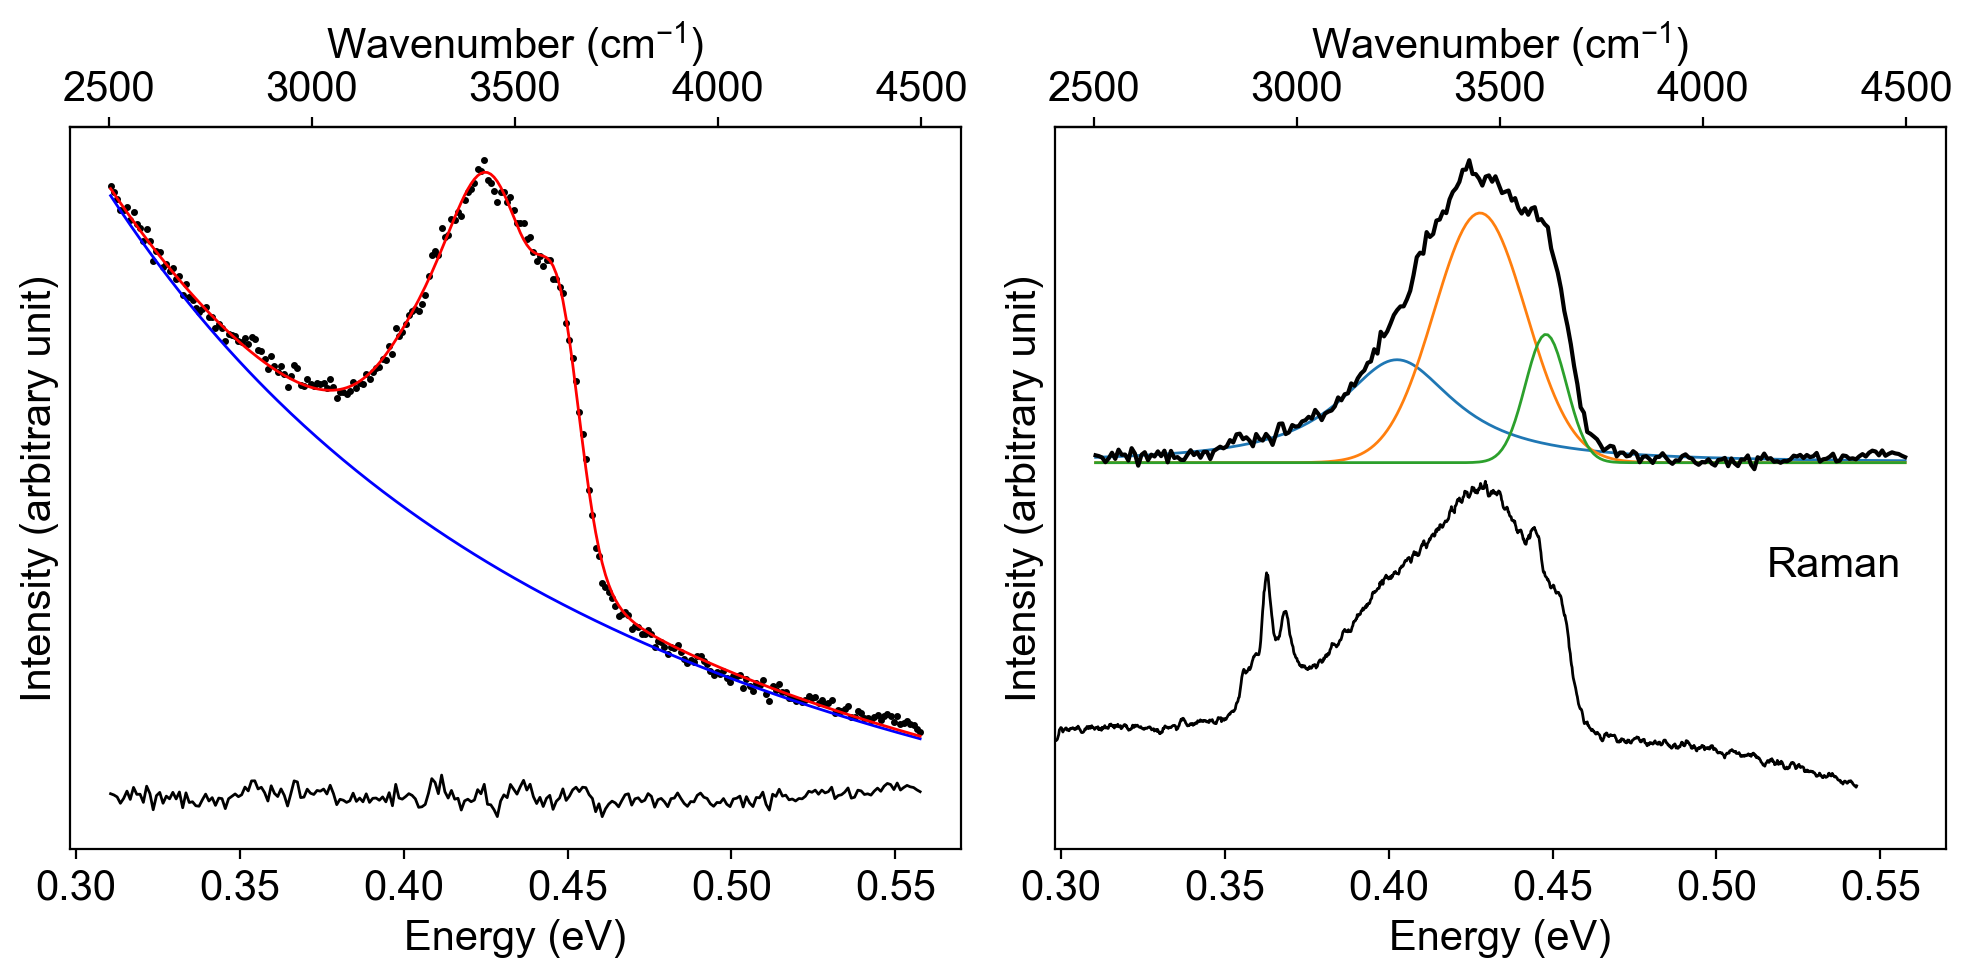

<Figure size 640x480 with 0 Axes>

In [229]:
# Adding the Raman into the plot
import pandas as pd

# plot offset
offset = 4500

file_path = './smoothed_Raman_ASU.csv'
ir_data = pd.read_csv(file_path, header=None)
x_lim = ax2[1].get_xlim()
y_lim = ax2[1].get_ylim()
ax2[1].plot(cmi_to_ev(ir_data[0]), (ir_data[1]-1800)*1.3-offset, 'k-', lw=1, zorder=0)
ax2[1].text(0.95, 0.42, "Raman", fontsize=15, va='top', ha='right', transform=ax2[1].transAxes, zorder=99)

ax2[1].set_xlim(x_lim)
# ax2[1].set_ylim(y_lim)

plt.tight_layout()
fig.savefig('SiO2 glass ball.pdf', format='pdf', bbox_inches='tight', transparent=True)
fig

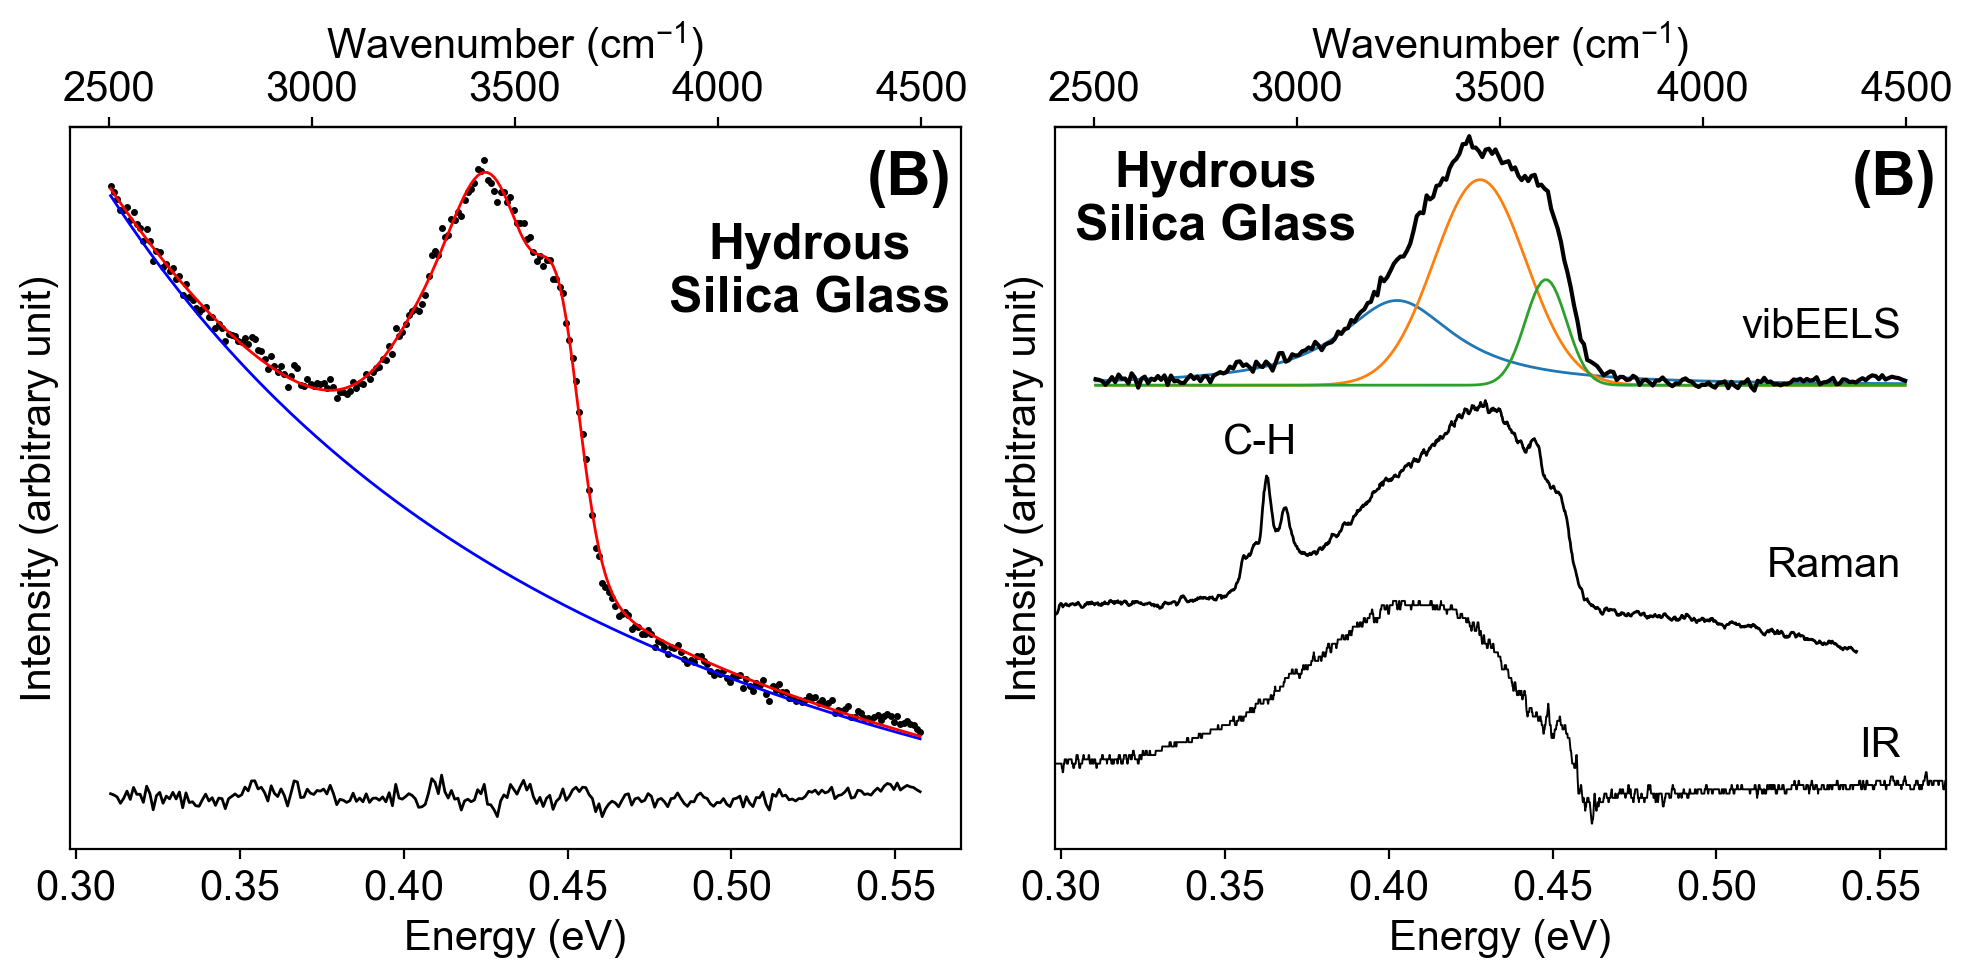

<Figure size 640x480 with 0 Axes>

In [230]:
# Adding the IR into the plot
import pandas as pd

# plot offset
offset = 8000

file_path = './IR_ASU_baked.csv'
ir_data = pd.read_csv(file_path, header=None)
x_lim = ax2[1].get_xlim()
y_lim = ax2[1].get_ylim()
ax2[1].plot(cmi_to_ev(ir_data[0]), (ir_data[1]+0.004)*830000-offset, 'k-', lw=0.7, zorder=0)
# ax2[1].text(0.7, 0.13, "IR_This study", fontsize=8, va='top', ha='left', transform=ax2[1].transAxes, zorder=99)
ax2[0].text(0.99, 0.93, "(B)", fontsize=22, weight='bold', va='center', ha='right', transform=ax2[0].transAxes, zorder=99)
ax2[0].text(0.83, 0.8, "Hydrous\nSilica Glass", fontsize=18, weight='bold', va='center', ha='center', transform=ax2[0].transAxes, zorder=99)
ax2[1].text(0.18, 0.9, "Hydrous\nSilica Glass", fontsize=18, weight='bold', va='center', ha='center', transform=ax2[1].transAxes, zorder=99)
ax2[1].text(0.99, 0.93, "(B)", fontsize=22, weight='bold', va='center', ha='right', transform=ax2[1].transAxes, zorder=99)
ax2[1].text(0.95, 0.75, "vibEELS", fontsize=15, va='top', ha='right', transform=ax2[1].transAxes, zorder=99)
ax2[1].text(0.95, 0.17, "IR", fontsize=15, va='top', ha='right', transform=ax2[1].transAxes, zorder=99)
ax2[1].text(0.23, 0.59, "C-H", fontsize=15, va='top', ha='center', transform=ax2[1].transAxes, zorder=99)

ax2[1].set_xlim(x_lim)
ax2[1].set_ylim(-9000, 5000)
# ax2[0].text(-0.055, 1, "(A)", fontsize=12, weight='bold', va='top', ha='left', transform=ax2[0].transAxes, zorder=99)
# ax2[1].text(-0.055, 1, "(B)", fontsize=12, weight='bold', va='top', ha='left', transform=ax2[1].transAxes, zorder=99)
# ax2[0].text(0.7, 0.45, "13.1 wt% water", fontsize=12, weight='bold', va='top', ha='left', transform=ax2[0].transAxes, zorder=99)
plt.tight_layout()
fig.savefig('SiO2 glass ball.pdf', format='pdf', bbox_inches='tight', transparent=True)
fig